In [18]:
import numpy as np, glob, re
from PIL import Image
import matplotlib.pyplot as plt
import os

IMG_DIR   = "new_ds/train" 
DEPTH_DIR = "new_ds/depth"
IMG_SIZE  = (512, 256)          # H, W
DMAX = 20.0

MODEL_IDS = {
    "metric_outdoor":  "depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf",   # vkitti, buat data jalananmu
    "metric_indoor":   "depth-anything/Depth-Anything-V2-Metric-Indoor-Large-hf",    # hypersim
    "relative":        "depth-anything/Depth-Anything-V2-Large-hf",
}

In [2]:
import torch
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

device = "cuda" if torch.cuda.is_available() else "cpu"
models = {}
for name, mid in MODEL_IDS.items():
    print("loading", name)
    proc = AutoImageProcessor.from_pretrained(mid)
    model = AutoModelForDepthEstimation.from_pretrained(mid).to(device).eval()
    models[name] = (proc, model)

loading metric_outdoor
loading metric_indoor
loading relative


In [25]:
imgs = sorted(glob.glob(f"{IMG_DIR}/*.png"))[:10]
print(f"Imgs length : {len(imgs)}")

Imgs length : 10


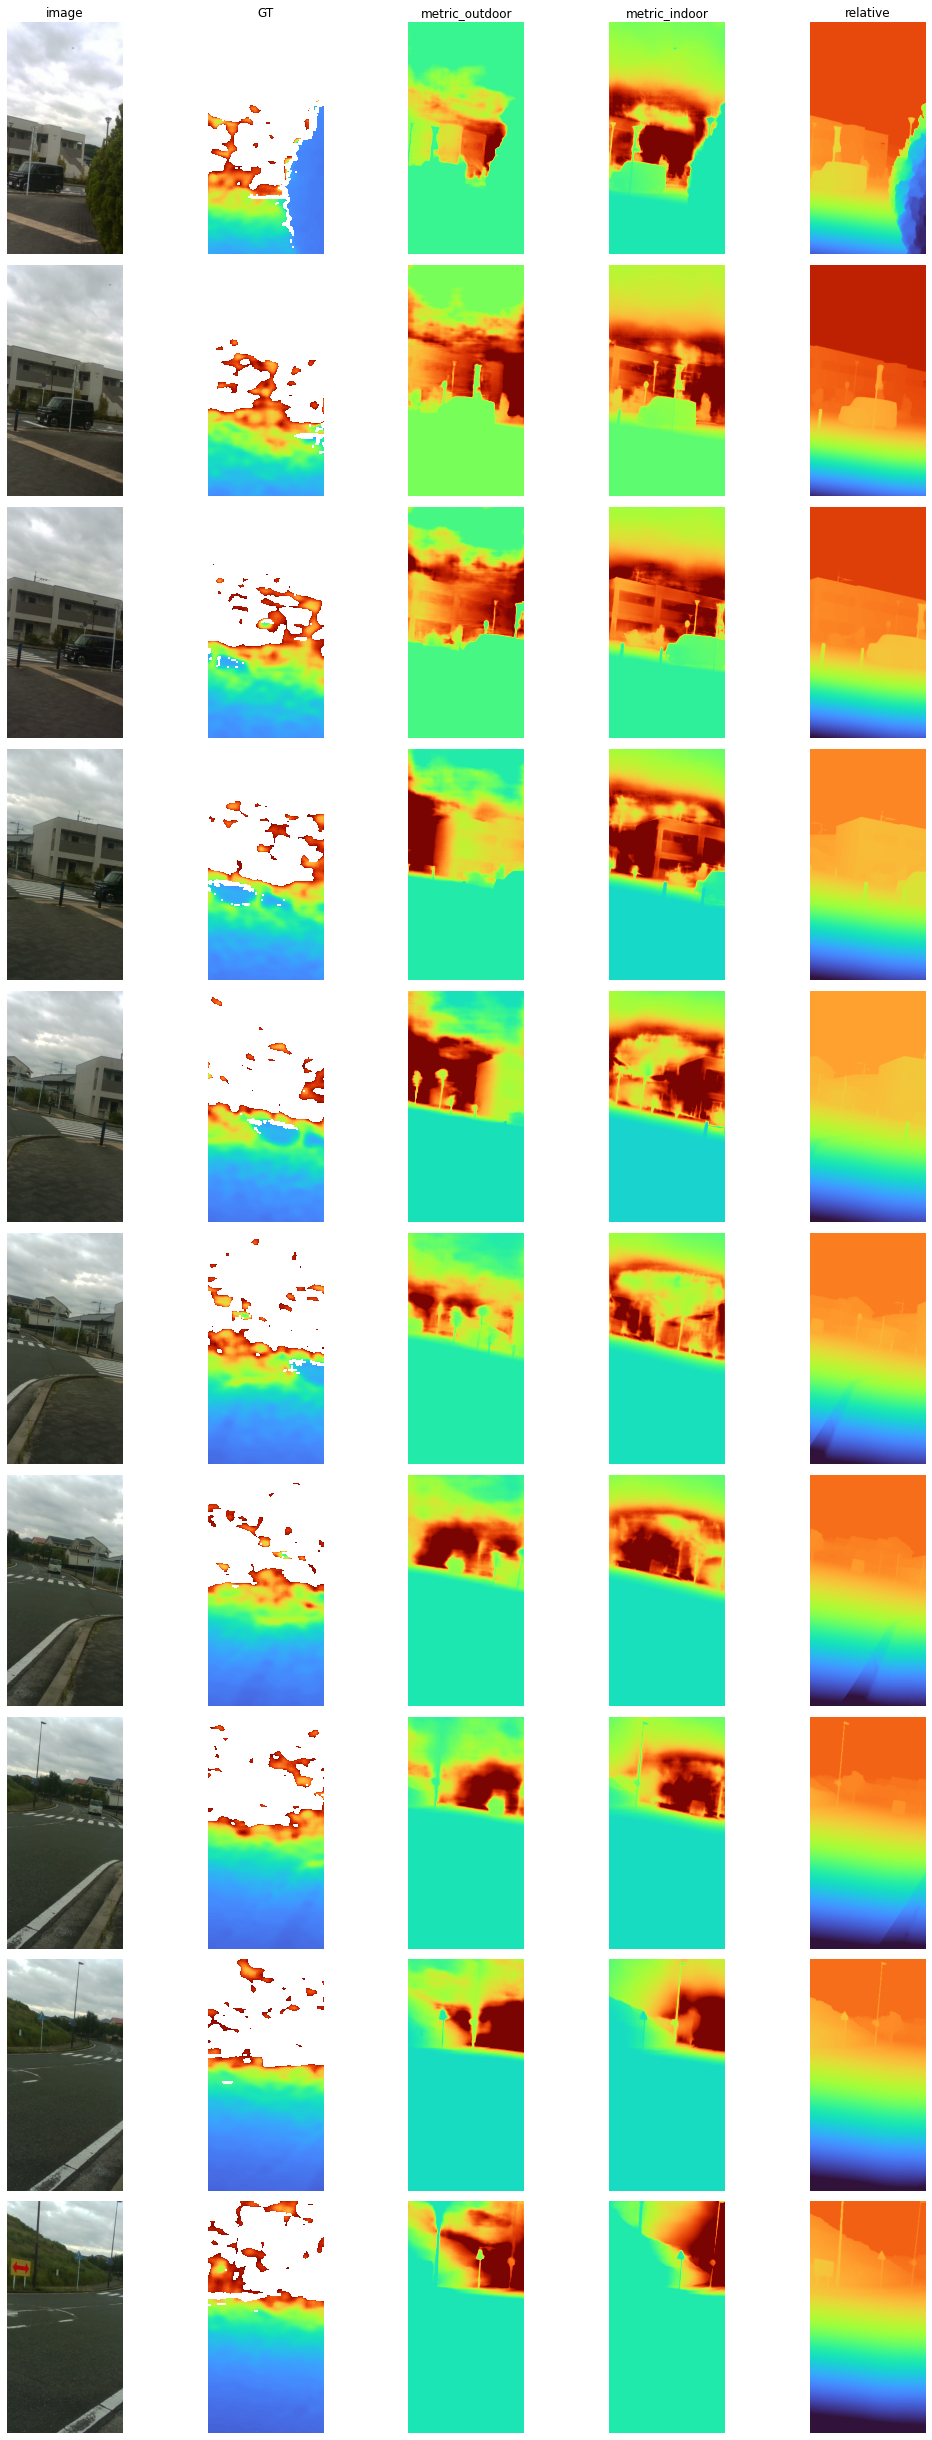

In [27]:
names = list(models.keys())
fig, axes = plt.subplots(len(imgs), 2 + len(names), figsize=(3*(2+len(names)), 3.4*len(imgs)))

for r, path in enumerate(imgs):
    fid = re.match(r"(\d{8}_\d{6}_\d+_\d+)", os.path.basename(path)).group(1)
    pil = Image.open(path).convert("RGB")

    # GT sensor
    gt = np.load(glob.glob(f"{DEPTH_DIR}/{fid}*.npy")[0]).astype(np.float32)
    gt = np.asarray(Image.fromarray(gt).resize((IMG_SIZE[1], IMG_SIZE[0]), Image.NEAREST)) / 1000.0
    valid = (gt > 0.001) & (gt < DMAX)

    axes[r,0].imshow(pil.resize((IMG_SIZE[1], IMG_SIZE[0]))); axes[r,0].axis("off")
    axes[r,1].imshow(np.where(valid, gt, np.nan), cmap="turbo", vmin=0, vmax=DMAX); axes[r,1].axis("off")
    if r == 0:
        axes[r,0].set_title("image"); axes[r,1].set_title("GT")

    for c, name in enumerate(names):
        proc, model = models[name]
        inp = proc(images=pil, return_tensors="pt").to(device)
        with torch.no_grad():
            pred = model(**inp).predicted_depth
        pred = torch.nn.functional.interpolate(
                pred.unsqueeze(1), 
                size=IMG_SIZE,
                mode="bilinear", 
                align_corners=False)[0,0].cpu().numpy()

        # kalibrasi ke GT biar bisa dibandingkan (a*pred+b)
        p, g = pred[valid], gt[valid]
        a, b = np.polyfit(p, g, 1)
        calib = a*pred + b
        corr = np.corrcoef(p, g)[0,1]
        mae = np.abs(calib[valid] - g).mean()

        axes[r,2+c].imshow(calib, cmap="turbo", vmin=0, vmax=DMAX); axes[r,2+c].axis("off")
        axes[r,2+c].set_xlabel(f"corr={corr:.2f} MAE={mae:.2f}")
        if r == 0: axes[r,2+c].set_title(name)

plt.tight_layout()
plt.show()

## Check teacher possibility

In [30]:
import numpy as np, glob, re, os
from PIL import Image
import torch

IMG_SIZE = (512, 256); DMAX = 20.0

# --- 1. INFER SEKALI, simpan semua prediksi mentah ---
preds = {name: [] for name in models}   # simpan pred mentah per model
gts, valids = [], []

for path in imgs:
    fid = re.match(r"(\d{8}_\d{6}_\d+_\d+)", os.path.basename(path)).group(1)
    pil = Image.open(path).convert("RGB")
    gt = np.load(glob.glob(f"{DEPTH_DIR}/{fid}*.npy")[0]).astype(np.float32)
    gt = np.asarray(Image.fromarray(gt).resize((IMG_SIZE[1], IMG_SIZE[0]), Image.NEAREST)) / 1000.0
    valid = (gt > 0.001) & (gt < DMAX)
    gts.append(gt); valids.append(valid)

    for name, (proc, model) in models.items():
        inp = proc(images=pil, return_tensors="pt").to(device)
        with torch.no_grad():
            pred = model(**inp).predicted_depth
        pred = torch.nn.functional.interpolate(pred.unsqueeze(1), size=IMG_SIZE,
                                                mode="bilinear", align_corners=False)[0,0].cpu().numpy()
        preds[name].append(pred)

print("inference selesai, sekarang hitung variasi (instan)")

inference selesai, sekarang hitung variasi (instan)


In [32]:
# --- 2. definisikan variasi transform (semua dari pred yang sama) ---
def t_linear(p):     
    return p                      # langsung, polyfit balik tanda

def t_invert(p):     
    return 1.0 / (p + 1e-6)       # 1/x

def t_neg(p):        
    return -p                      # balik tanda manual

def t_log(p):        
    return np.log(p + 1e-6)        # log

transforms = {"linear": t_linear, "invert": t_invert, "neg": t_neg, "log": t_log}

In [33]:
print(f"\n{'model':16s} {'transform':10s} {'|corr|':>7s} {'MAE(m)':>7s}")
for name in models:
    for tname, tf in transforms.items():
        corrs, maes = [], []
        for pred, gt, valid in zip(preds[name], gts, valids):
            x = tf(pred)
            p, g = x[valid], gt[valid]
            if not np.all(np.isfinite(p)):  # jaga-jaga log/invert nan
                continue
            a, b = np.polyfit(p, g, 1)
            calib = a*x + b
            corrs.append(abs(np.corrcoef(p, g)[0,1]))
            maes.append(np.abs(calib[valid] - g).mean())
        if corrs:
            print(f"{name:16s} {tname:10s} {np.mean(corrs):7.3f} {np.mean(maes):7.3f}")


model            transform   |corr|  MAE(m)
metric_outdoor   linear       0.550   3.467
metric_outdoor   invert       0.709   2.809
metric_outdoor   neg          0.550   3.467
metric_outdoor   log          0.709   2.811
metric_indoor    linear       0.658   3.052
metric_indoor    invert       0.756   2.561
metric_indoor    neg          0.658   3.052
metric_indoor    log          0.771   2.480
relative         linear       0.873   1.931
relative         invert       0.390   3.776
relative         neg          0.873   1.931
relative         log          0.544   3.418


## Using relative + linear calibration (polyfit) to gt sensor

In [34]:
import numpy as np, glob, re, os
from PIL import Image
import torch

# --- konfigurasi ---
IMG_DIR   = "new_ds/train"          # folder gambar
DEPTH_DIR = "new_ds/Depth"          # GT sensor .npy
OUT_DIR   = "new_ds/Teacher"        # output teacher .npy
IMG_SIZE  = (512, 256)              # H, W
DMAX      = 20.0
os.makedirs(OUT_DIR, exist_ok=True)

proc, model = models["relative"]    # pakai relative yang sudah di-load

# --- kumpulkan daftar gambar ---
imgs = sorted(glob.glob(f"{IMG_DIR}/*.png"))
print("total gambar:", len(imgs))

calib_log = {}       # simpan a,b per frame biar bisa dicek nanti
skipped = []

for k, path in enumerate(imgs):
    fid = re.match(r"(\d{8}_\d{6}_\d+_\d+)", os.path.basename(path)).group(1)
    out_path = f"{OUT_DIR}/{fid}.npy"
    if os.path.exists(out_path):     # resume: lewati yang sudah ada
        continue

    pil = Image.open(path).convert("RGB")

    # GT sensor
    gt_hits = glob.glob(f"{DEPTH_DIR}/{fid}*.npy")
    if not gt_hits:
        skipped.append(fid); continue
    gt = np.load(gt_hits[0]).astype(np.float32)
    gt = np.asarray(Image.fromarray(gt).resize((IMG_SIZE[1], IMG_SIZE[0]), Image.NEAREST)) / 1000.0
    valid = (gt > 0.001) & (gt < DMAX)
    if valid.sum() < 50:             # terlalu sedikit titik utk kalibrasi
        skipped.append(fid); continue

    # inference relative
    inp = proc(images=pil, return_tensors="pt").to(device)
    with torch.no_grad():
        pred = model(**inp).predicted_depth
    pred = torch.nn.functional.interpolate(pred.unsqueeze(1), size=IMG_SIZE,
                                           mode="bilinear", align_corners=False)[0,0].cpu().numpy()

    # kalibrasi linear ke GT sensor
    a, b = np.polyfit(pred[valid], gt[valid], 1)
    teacher = (a * pred + b).astype(np.float32)

    np.save(out_path, teacher)
    calib_log[fid] = (float(a), float(b))

    if (k+1) % 100 == 0:
        print(f"[{k+1}/{len(imgs)}]  a={a:.3f} b={b:.3f}")

# simpan log kalibrasi
np.save(f"{OUT_DIR}/_calib_log.npy", calib_log)
print("selesai. tersimpan di", OUT_DIR)
print("dilewati (tanpa GT cukup):", len(skipped))

total gambar: 1000
[100/1000]  a=-0.017 b=14.001
[200/1000]  a=-0.019 b=12.943
[300/1000]  a=-0.013 b=11.039
[400/1000]  a=-0.016 b=11.828
[500/1000]  a=-0.024 b=15.743
[600/1000]  a=-0.013 b=9.864
[700/1000]  a=-0.022 b=18.079
[800/1000]  a=-0.020 b=11.591
[900/1000]  a=-0.019 b=9.974
[1000/1000]  a=-0.015 b=12.386
selesai. tersimpan di new_ds/Teacher
dilewati (tanpa GT cukup): 0
